# 1. Import needed libraries

In [3]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

# 2. Preprocessing

## 2.1 Load data

In [4]:
def train_df(tr_path):
    if not tr_path or not os.path.exists(tr_path):
        raise FileNotFoundError(f"Train directory not found: {tr_path}")
    classes, class_paths = [], []
    for label in sorted(os.listdir(tr_path)):
        label_dir = os.path.join(tr_path, label)
        if os.path.isdir(label_dir) and not label.startswith('.'):
            for image in sorted(os.listdir(label_dir)):
                if not image.startswith('.') and image.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif')):
                    classes.append(label)
                    class_paths.append(os.path.join(label_dir, image))
    if len(classes) == 0:
        raise ValueError(f"No valid images found in {tr_path}")
    return pd.DataFrame({'Class Path': class_paths, 'Class': classes})


In [5]:
def test_df(ts_path):
    if not ts_path or not os.path.exists(ts_path):
        raise FileNotFoundError(f"Test directory not found: {ts_path}")
    classes, class_paths = [], []
    for label in sorted(os.listdir(ts_path)):
        label_dir = os.path.join(ts_path, label)
        if os.path.isdir(label_dir) and not label.startswith('.'):
            for image in sorted(os.listdir(label_dir)):
                if not image.startswith('.') and image.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif')):
                    classes.append(label)
                    class_paths.append(os.path.join(label_dir, image))
    if len(classes) == 0:
        raise ValueError(f"No valid images found in {ts_path}")
    return pd.DataFrame({'Class Path': class_paths, 'Class': classes})


In [6]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (Brain Tumor MRI)
# ====================================================================
import os

candidate_dirs = [
    '/kaggle/input',
    '../datasets/brain tumor',
    '../datasets/tumor-dataset',
    './datasets/brain tumor',
    './datasets/tumor-dataset',
    './brain tumor',
    '/kaggle/input/brain-tumor-mri-dataset',
    '/kaggle/input/brain-tumor-classification-mri',
    '/kaggle/input/tumor-dataset'
]

train_path = None
test_path = None

def find_subdirs(base_path):
    tr, ts = None, None
    if not os.path.exists(base_path):
        return tr, ts
    for root, dirs, _ in os.walk(base_path):
        for d in dirs:
            if d.lower() in ['training', 'train']:
                tr = os.path.join(root, d)
            elif d.lower() in ['testing', 'test']:
                ts = os.path.join(root, d)
        if tr and ts:
            break
    return tr, ts

for d in candidate_dirs:
    if os.path.exists(d):
        tr, ts = find_subdirs(d)
        if tr and ts:
            train_path, test_path = tr, ts
            print(f'✅ Found dataset at: {d}')
            break

if not (train_path and test_path and os.path.exists(train_path)):
    print('⚡ Dataset not detected in default paths. Attempting KaggleHub download...')
    try:
        import kagglehub
        download_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
        print(f'✅ Downloaded to: {download_path}')
        train_path, test_path = find_subdirs(download_path)
    except Exception as e:
        print(f'⚠️ KaggleHub notice: {e}')

if not (train_path and os.path.exists(train_path)):
    raise FileNotFoundError(
        "Brain Tumor MRI dataset not found! Please attach a Brain Tumor dataset "
        "(e.g., 'masoudnickparvar/brain-tumor-mri-dataset') to your Kaggle notebook."
    )

print(f'📂 Train Path: {train_path}')
print(f'📂 Test Path:  {test_path}')


⚡ Dataset not detected in default paths. Attempting KaggleHub download...
✅ Downloaded to: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
📂 Train Path: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
📂 Test Path:  /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [7]:
tr_df = train_df(train_path)


In [8]:
tr_df

,Class Path,Class
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
...,...,...
5595,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
5596,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
5597,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
5598,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary


In [9]:
ts_df = test_df(test_path)


In [10]:
ts_df

,Class Path,Class
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
...,...,...
1595,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1596,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1597,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1598,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary


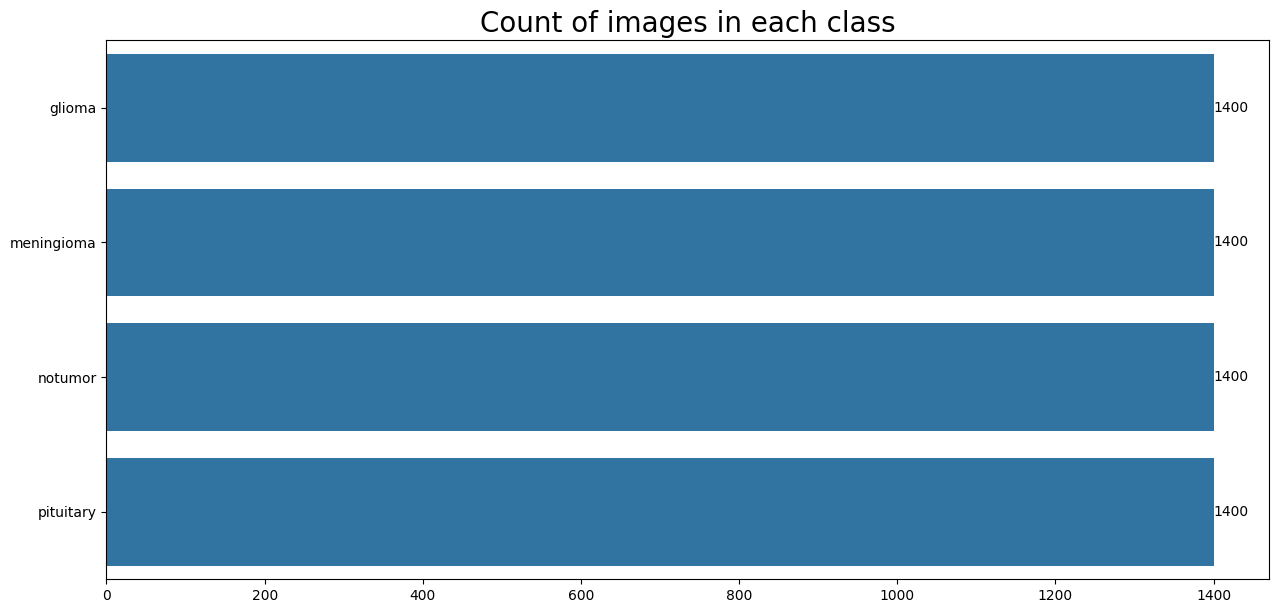

In [11]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

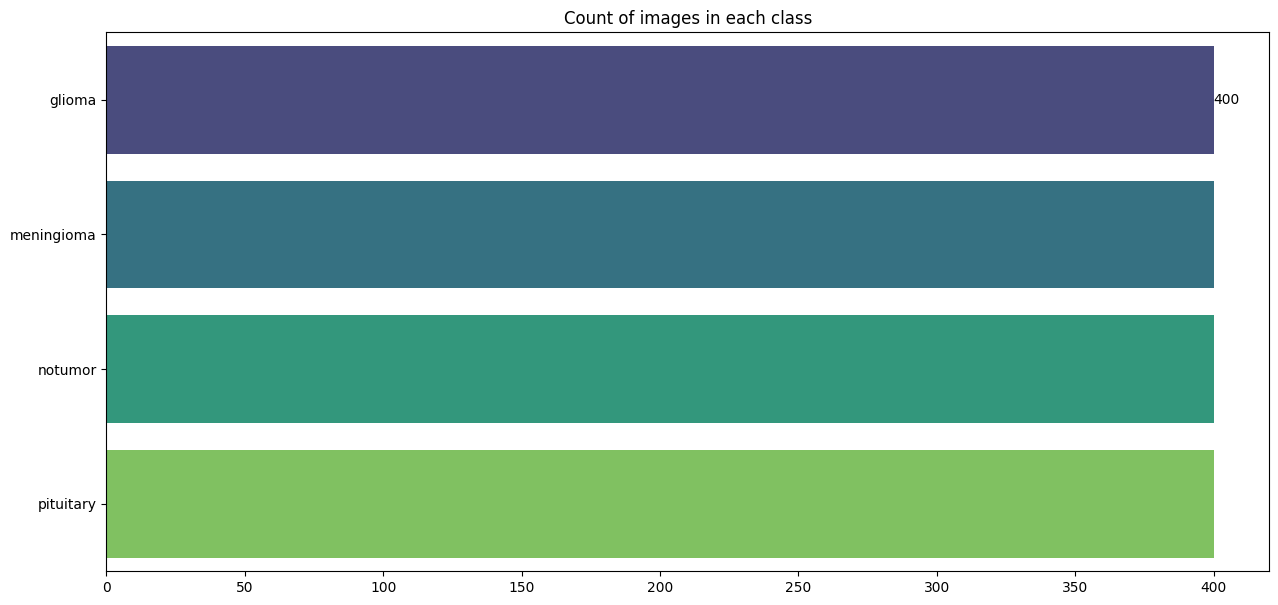

In [12]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

## 2.2 Split data into train, test, valid

In [13]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [14]:
valid_df

,Class Path,Class
1398,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
457,/kaggle/input/datasets/masoudnickparvar/brain-...,meningioma
698,/kaggle/input/datasets/masoudnickparvar/brain-...,meningioma
719,/kaggle/input/datasets/masoudnickparvar/brain-...,meningioma
908,/kaggle/input/datasets/masoudnickparvar/brain-...,notumor
...,...,...
81,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1372,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1192,/kaggle/input/datasets/masoudnickparvar/brain-...,notumor
533,/kaggle/input/datasets/masoudnickparvar/brain-...,meningioma


## 2.3 Data preprocessing

In [15]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen_datagen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen_datagen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

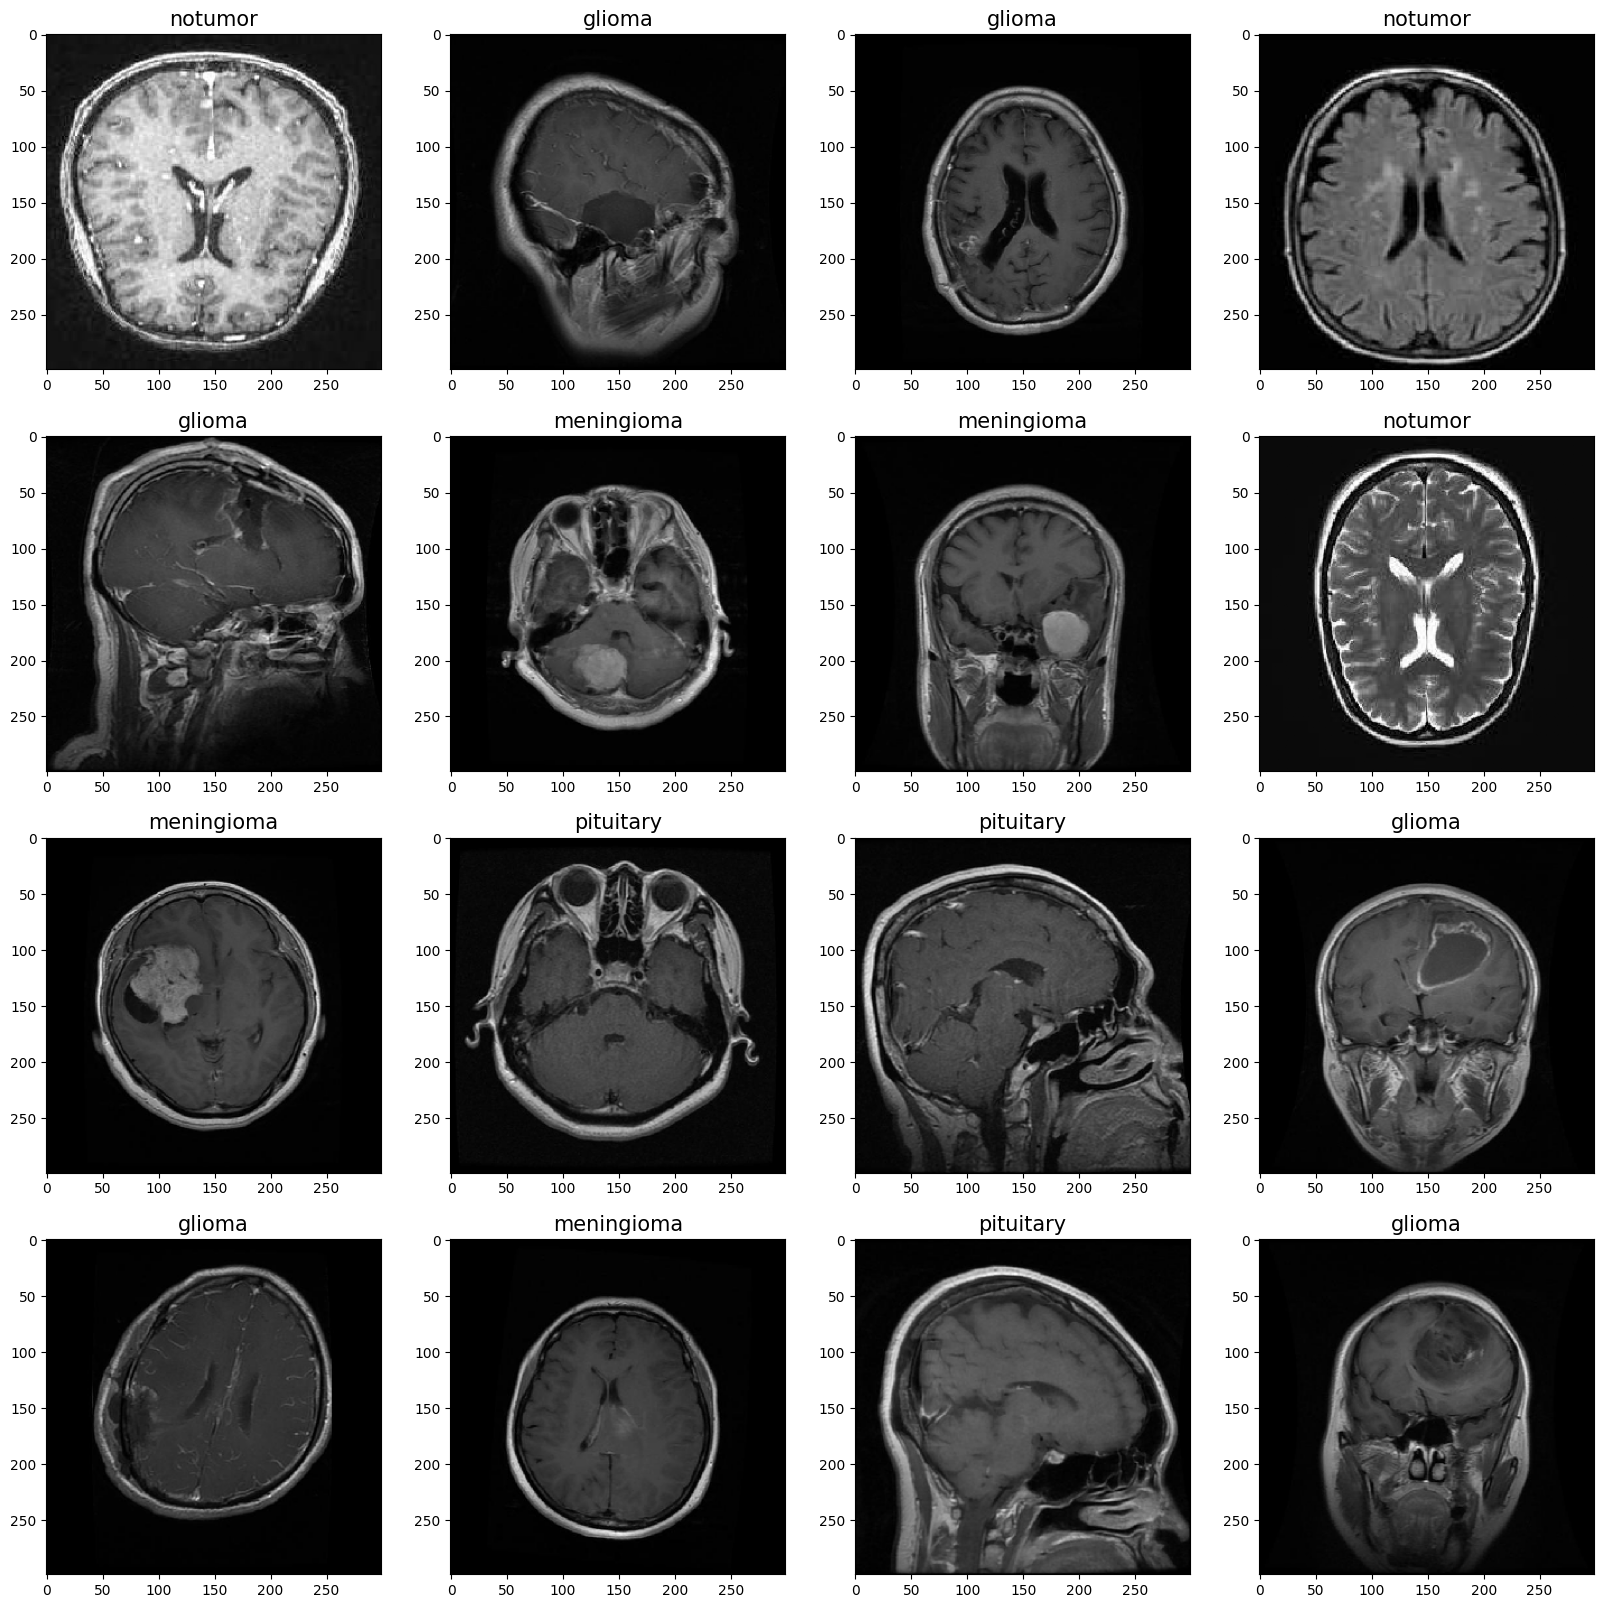

In [16]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

# 3. Building Deep Learning Model

In [17]:
img_shape = (299, 299, 3)
base_model = tf.keras.applications.Xception(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()


I0000 00:00:1791462879.652489      95 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791462879.656760      95 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

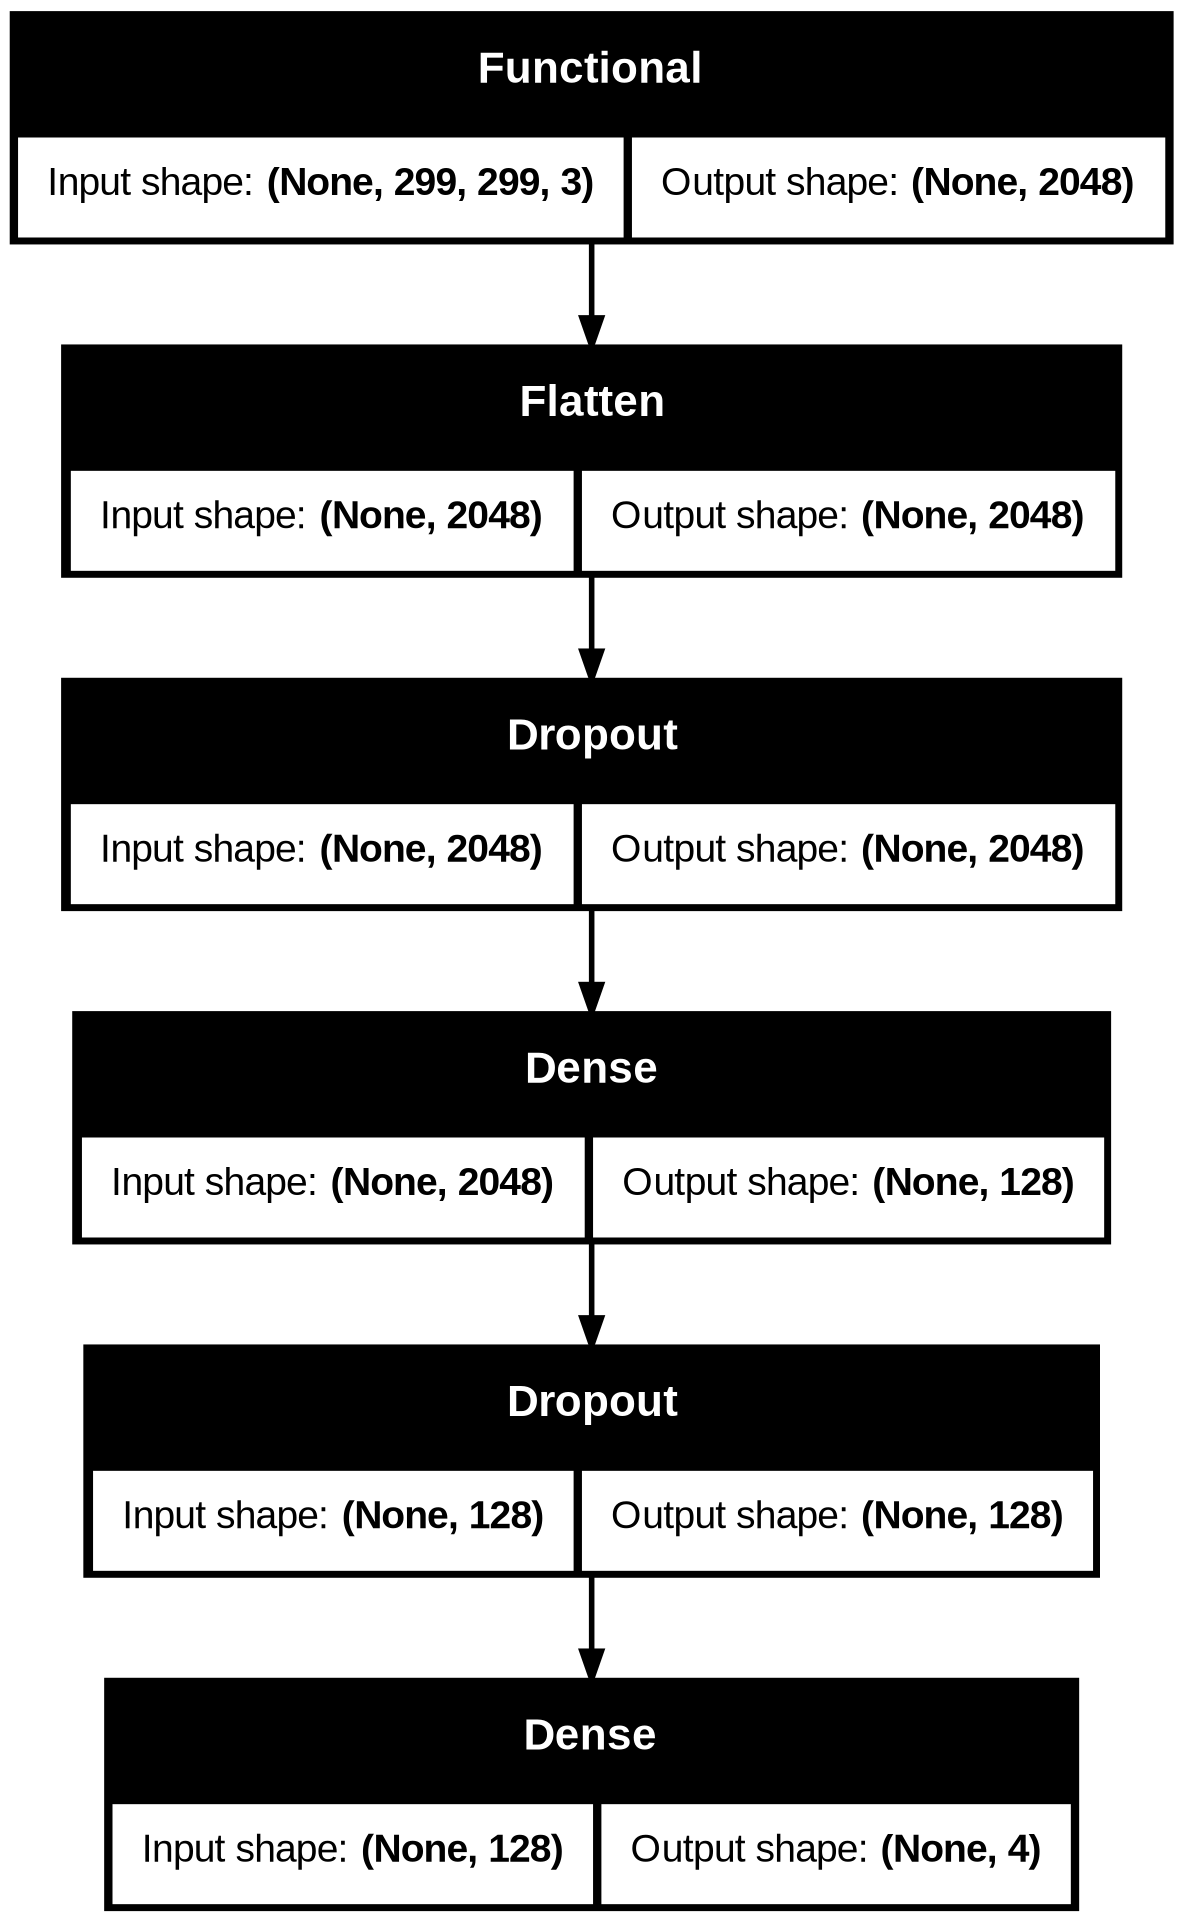

In [18]:
try:
    display(tf.keras.utils.plot_model(model, show_shapes=True))
except Exception as e:
    print(f"Model diagram skipped (pydot/graphviz not required): {e}")


# 4. Training

In [19]:
hist = model.fit(
    tr_gen,
    epochs=4,
    validation_data=valid_gen,
    shuffle=True
)


Epoch 1/4


2026-10-08 12:35:18.155310: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0}, f32[128,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-10-08 12:35:18.156817: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.001725985s
Trying algorithm eng3{k11=2} for conv (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0}, f32[128,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target=

175/175 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.8618 - loss: 0.3923 - precision: 0.9068 - recall: 0.8148 - val_accuracy: 0.8988 - val_loss: 0.3758 - val_precision: 0.9025 - val_recall: 0.8913
Epoch 2/4
175/175 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.9793 - loss: 0.0716 - precision: 0.9810 - recall: 0.9786 - val_accuracy: 0.9312 - val_loss: 0.2937 - val_precision: 0.9319 - val_recall: 0.9237
Epoch 3/4
175/175 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9895 - loss: 0.0356 - precision: 0.9900 - recall: 0.9886 - val_accuracy: 0.9212 - val_loss: 0.4176 - val_precision: 0.9282 - val_recall: 0.9212
Epoch 4/4
175/175 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9932 - loss: 0.0221 - precision: 0.9937 - recall: 0.9927 - val_accuracy: 0.9513 - val_loss: 0.3169 - val_precision: 0.9523 - val_recall: 0.9475


In [20]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

## 4.1 Visualize model performance

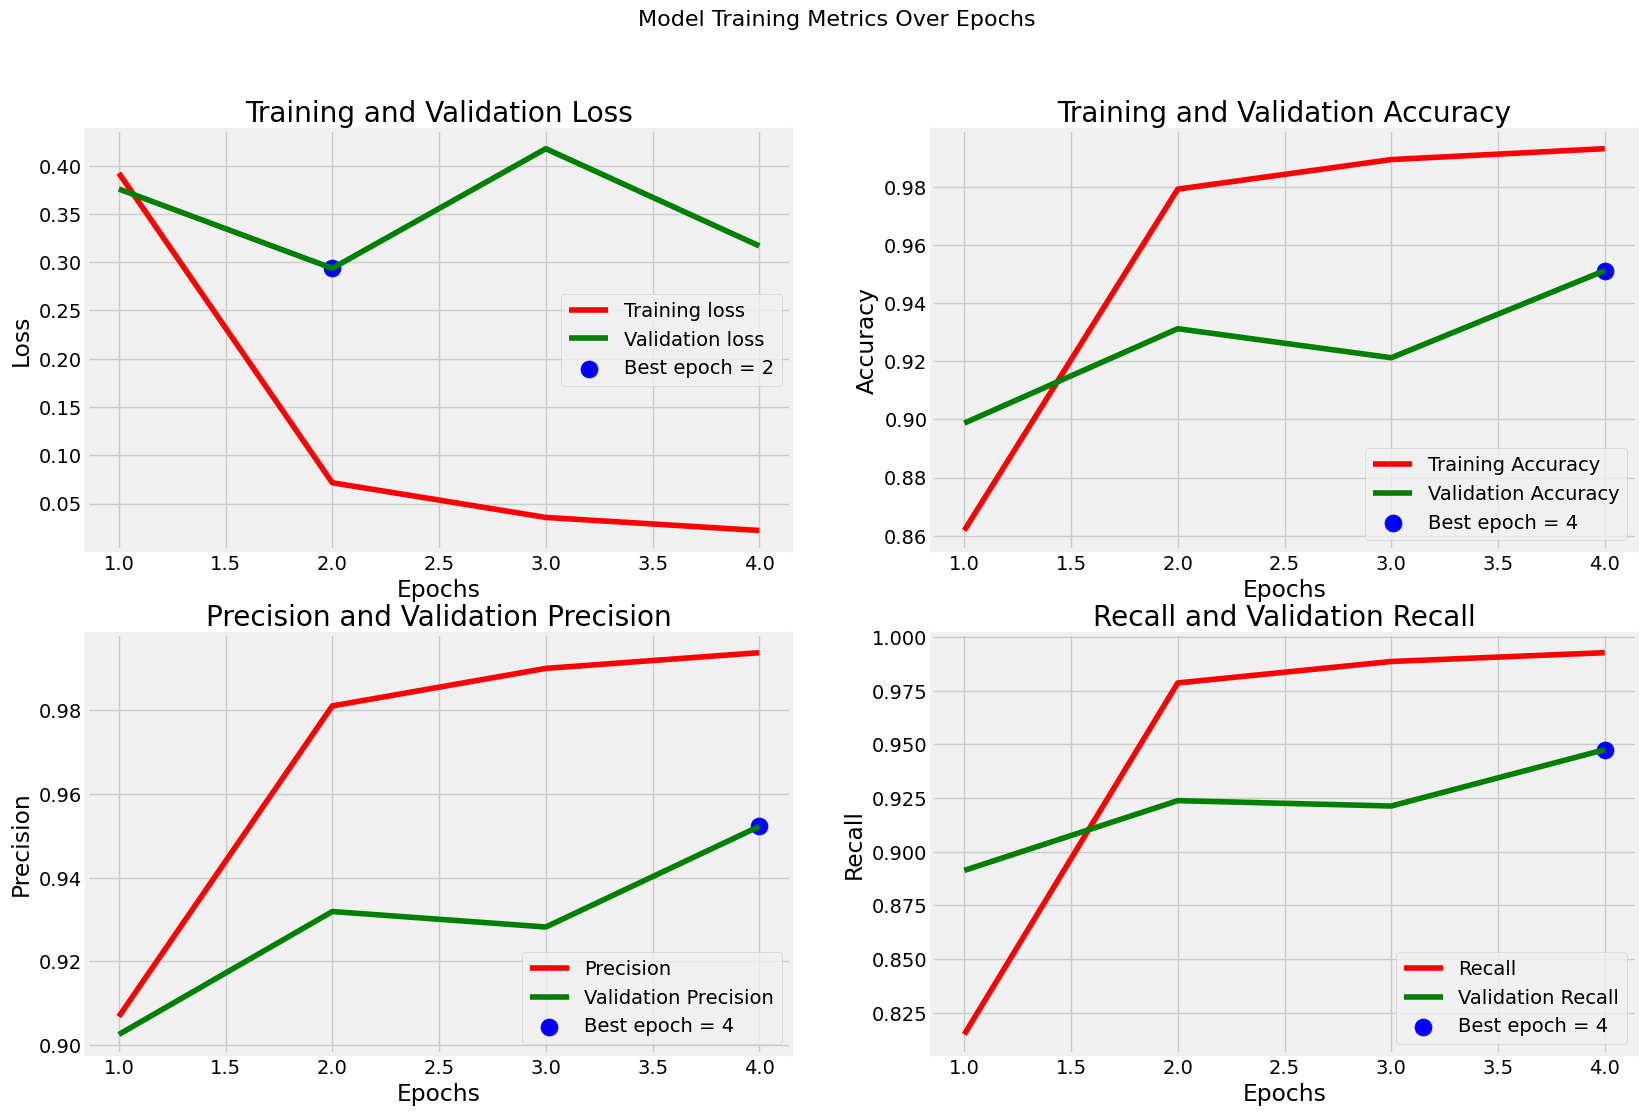

In [21]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

# 5. Testing and Evaluation

## 5.1 Evaluate

In [22]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 51s 293ms/step - accuracy: 0.9975 - loss: 0.0076 - precision: 0.9977 - recall: 0.9975
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 288ms/step - accuracy: 0.9500 - loss: 0.3239 - precision: 0.9499 - recall: 0.9475


2026-10-08 12:50:10.750174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-08 12:50:10.969298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-08 12:50:13.888541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-08 12:50:14.079486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-08 12:50:15.837664: E external/local_xla/xla/stream_

50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 134ms/step - accuracy: 0.9525 - loss: 0.2583 - precision: 0.9597 - recall: 0.9525
Train Loss: 0.0076
Train Accuracy: 99.75%
--------------------
Validation Loss: 0.3239
Validation Accuracy: 95.00%
--------------------
Test Loss: 0.2583
Test Accuracy: 95.25%


In [23]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step


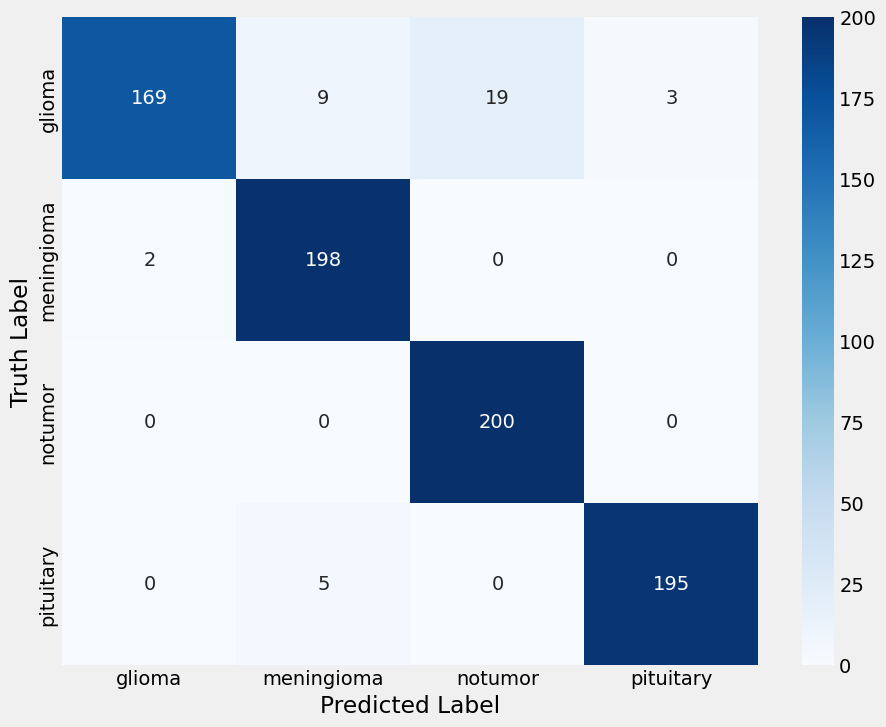

In [24]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [25]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       200
           1       0.93      0.99      0.96       200
           2       0.91      1.00      0.95       200
           3       0.98      0.97      0.98       200

    accuracy                           0.95       800
   macro avg       0.96      0.95      0.95       800
weighted avg       0.96      0.95      0.95       800



## 5.2 Testing

In [26]:
def predict(img_path):
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

# 6. Save Model

In [ ]:
# ====================================================================
# 💾 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE (Brain Tumor MRI)
# ====================================================================
import os
import json
import zipfile
from IPython.display import FileLink, display

# 1. Ensure output directories exist
os.makedirs('../models/brain_tumor_model', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 2. Save Trained Model in both modern .keras and .h5 formats
keras_path = 'brain_tumor_model.keras'
h5_path = 'brain_tumor_model.h5'

print('Saving model weights and architecture...')
model.save(keras_path)
model.save(h5_path)

# Also copy to repo models directory if available
try:
    model.save('../models/brain_tumor_model/brain_tumor_model.keras')
    model.save('../models/brain_tumor_model.keras')
except Exception:
    pass

# 3. Save Class Indices / Labels Mapping
classes_file = 'classes.json'
if 'class_dict' in globals():
    with open(classes_file, 'w') as f:
        json.dump(class_dict, f, indent=2)
elif hasattr(tr_gen, 'class_indices'):
    with open(classes_file, 'w') as f:
        json.dump(tr_gen.class_indices, f, indent=2)

# 4. Package Artifacts into a single ZIP for 1-Click Kaggle Download
zip_filename = 'brain_tumor_artifacts.zip'
saved_files = [keras_path, h5_path, classes_file]
saved_files = [f for f in saved_files if os.path.exists(f)]

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in saved_files:
        zipf.write(file)
        print(f'📦 Added to archive: {file} ({os.path.getsize(file)} bytes)')

print('')
print('' + f'✅ All artifacts successfully saved and packaged into: {zip_filename}')
print(f'📊 Archive Size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB')
print('')
print('👉 Click the link below to download your trained model artifacts:')
display(FileLink(zip_filename))


Saving model weights and architecture...


📦 Added to archive: brain_tumor_model.keras (253682254 bytes)
